<a href="https://colab.research.google.com/github/kunalan-Subatharan/Beijing-Air-Quality-Analysis/blob/main/CMP7005_PRAC1_Beijing_Air_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CMP7005 - Programming for Data Analysis**
## **PRAC1: From Data to Application Development**

---

## **Task 1 – Data Selection & Handling**

### **Station Selection & Justification:**

| Station | Type | Justification |
|---|---|---|
| **Dongsi** | Inner (Urban) | Located in dense urban core, Dongcheng District. Low missing data (2.1%). Canonical urban pollution station in literature. |
| **Guanyuan** | Inner (Urban) | Located in Xicheng District urban core. Lowest missing PM2.5 rate (1.8%) among urban stations. |
| **Dingling** | Outer (Suburban) | Northern suburban fringe, ~50km from city centre. Represents background pollution levels. |
| **Changping** | Outer (Suburban) | Northern satellite town. Frequently used in Beijing air quality studies for urban-suburban comparison. |

In [2]:
# Importing the necessary libraries for data analysis
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [3]:
! git config --global user.name "kunalan-Subatharan"
! git config --global user.email "kunalankuna04@gmail.com"

In [4]:
username = "kunalan-Subatharan"
repo = "Beijing-Air-Quality-Analysis"

In [5]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'Beijing-Air-Quality-Analysis'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 32 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 2.81 MiB | 3.63 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [6]:
%cd {repo}

/content/Beijing-Air-Quality-Analysis


## **Navigating into the Data Folder**

After cloning the repository, the working directory is set to the root of the repo.
Since My 4 selected station CSV files are stored inside the `data/` folder,
I need to change the directory into `data/` before I can load the files.

This ensures Python can locate and read the CSV files correctly.


In [7]:
%cd data

/content/Beijing-Air-Quality-Analysis/data


In [8]:
%ls

PRSA_Data_Changping_20130301-20170228.csv
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Guanyuan_20130301-20170228.csv


## **Loading and Merging the 4 Selected Station Datasets**

### **🧩 Merging of the CSV files:**

I specifically load only those 4 selected stations from the `data/` folder:
- **Urban:** Dongsi, Guanyuan
- **Suburban:** Dingling, Changping

In [9]:
# Define the 4 selected stations (2 inner urban + 2 outer suburban)
selected_stations = [
    "PRSA_Data_Dongsi_20130301-20170228.csv",      # Inner (Urban)
    "PRSA_Data_Guanyuan_20130301-20170228.csv",    # Inner (Urban)
    "PRSA_Data_Dingling_20130301-20170228.csv",    # Outer (Suburban)
    "PRSA_Data_Changping_20130301-20170228.csv"    # Outer (Suburban)
]

#Create an empty list to store all station data
all_stations_data = []

# Read each selected station file one by one
for file_name in selected_stations:
  station_df = pd.read_csv(file_name)

  # Add this station's data to The list
  all_stations_data.append(station_df)

  # Print which file loaded and how many rows it has
  print(f"Loaded: {file_name} | Rows: {len(station_df)}")

print(f"\n✅ Successfully loaded {len(all_stations_data)} station files")



Loaded: PRSA_Data_Dongsi_20130301-20170228.csv | Rows: 35064
Loaded: PRSA_Data_Guanyuan_20130301-20170228.csv | Rows: 35064
Loaded: PRSA_Data_Dingling_20130301-20170228.csv | Rows: 35064
Loaded: PRSA_Data_Changping_20130301-20170228.csv | Rows: 35064

✅ Successfully loaded 4 station files


In [10]:
# Combine all 4 station datasets into one big table
combined_data = pd.concat(all_stations_data, ignore_index=True)

# Create a proper datetime column from year, month, day, hour columns
combined_data['datetime'] = pd.to_datetime(
    combined_data[['year', 'month', 'day', 'hour']]
)

# Add a station_type column to distinguish urban vs suburban stations
station_type_map = {
    'Dongsi'    : 'Urban',
    'Guanyuan'  : 'Urban',
    'Dingling'  : 'Suburban',
    'Changping' : 'Suburban'
}

combined_data['station_type'] = combined_data['station'].map(station_type_map)

# Save the combined data to a new CSV file
combined_data.to_csv("beijing_air_quality_combined.csv", index=False)

print(f"SUCCESS: Combined {len(selected_stations)} station files into one dataset")
print(f"Total Rows: {len(combined_data):,}")
print(f"Total Columns: {combined_data.shape[1]}")
print("The combined file is saved as: beijing_air_quality_combined.csv")


SUCCESS: Combined 4 station files into one dataset
Total Rows: 140,256
Total Columns: 20
The combined file is saved as: beijing_air_quality_combined.csv


In [11]:
df = pd.read_csv('beijing_air_quality_combined.csv')
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,station_type
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01 00:00:00,Urban
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,2013-03-01 01:00:00,Urban
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,2013-03-01 02:00:00,Urban
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,2013-03-01 03:00:00,Urban
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,2013-03-01 04:00:00,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,28.0,47.0,4.0,14.0,300.0,NaN,11.7,1008.9,-13.3,0.0,NNE,1.3,Changping,2017-02-28 19:00:00,Suburban
140252,35061,2017,2,28,20,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1,Changping,2017-02-28 20:00:00,Suburban
140253,35062,2017,2,28,21,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5,Changping,2017-02-28 21:00:00,Suburban
140254,35063,2017,2,28,22,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4,Changping,2017-02-28 22:00:00,Suburban


## **Exploratory Data Analysis(EDA)**

### **1. Data Understanding**

In this section, I explore the structure and quality of the merged dataset including the number of rows and columns, column descriptions, data types, missing values, and a statistical summary.

In [12]:
# Shape - number of rows and columns
print(f'Number of Rows: {df.shape[0]:,}')
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 140,256
Number of Columns: 20


In [13]:
# Column descriptions - what each column means
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   No            140256 non-null  int64  
 1   year          140256 non-null  int64  
 2   month         140256 non-null  int64  
 3   day           140256 non-null  int64  
 4   hour          140256 non-null  int64  
 5   PM2.5         137337 non-null  float64
 6   PM10          138036 non-null  float64
 7   SO2           137761 non-null  float64
 8   NO2           136095 non-null  float64
 9   CO            131773 non-null  float64
 10  O3            136601 non-null  float64
 11  TEMP          140110 non-null  float64
 12  PRES          140116 non-null  float64
 13  DEWP          140110 non-null  float64
 14  RAIN          140114 non-null  float64
 15  wd            139817 non-null  object 
 16  WSPM          140142 non-null  float64
 17  station       140256 non-null  object 
 18  date

In [14]:
# Data types of each column
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [15]:
# Preview first 5 rows
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,station_type
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,2013-03-01 00:00:00,Urban
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,2013-03-01 01:00:00,Urban
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,2013-03-01 02:00:00,Urban
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,2013-03-01 03:00:00,Urban
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,2013-03-01 04:00:00,Urban


In [16]:
# Preview last 5 rows
df.tail()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,station_type
140251,35060,2017,2,28,19,28.0,47.0,4.0,14.0,300.0,NaN,11.7,1008.9,-13.3,0.0,NNE,1.3,Changping,2017-02-28 19:00:00,Suburban
140252,35061,2017,2,28,20,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1,Changping,2017-02-28 20:00:00,Suburban
140253,35062,2017,2,28,21,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5,Changping,2017-02-28 21:00:00,Suburban
140254,35063,2017,2,28,22,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4,Changping,2017-02-28 22:00:00,Suburban
140255,35064,2017,2,28,23,20.0,25.0,6.0,28.0,900.0,54.0,7.0,1009.4,-12.2,0.0,N,1.9,Changping,2017-02-28 23:00:00,Suburban


In [17]:
# Total stations and their row counts
stations = df['station'].value_counts()
print(f'Total number of stations: {len(stations)}')
stations

Total number of stations: 4


,count
station,
Dongsi,35064
Guanyuan,35064
Dingling,35064
Changping,35064


In [18]:
# Station type breakdown (Urban vs Suburban)
print(df.groupby(['station', 'station_type']).size().reset_index(name='row_count').to_string(index=False))

  station station_type  row_count
Changping     Suburban      35064
 Dingling     Suburban      35064
   Dongsi        Urban      35064
 Guanyuan        Urban      35064


In [19]:
# Statistical summary
df.describe().round(2)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.00,140256.00,140256.00,140256.00,140256.00,137337.00,138036.00,137761.00,136095.00,131773.00,136601.00,140110.00,140116.00,140110.00,140114.00,140142.00
mean,17532.50,2014.66,6.52,15.73,11.50,76.56,99.46,15.71,45.87,1163.32,59.85,13.66,1009.98,2.15,0.06,1.82
std,10122.14,1.18,3.45,8.80,6.92,78.70,89.17,21.16,33.54,1107.71,56.15,11.40,10.52,13.80,0.80,1.28
min,1.00,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-16.80,982.40,-35.30,0.00,0.00
25%,8766.75,2014.00,4.00,8.00,5.75,19.00,34.00,3.00,20.00,500.00,15.85,3.30,1001.40,-9.40,0.00,1.00
50%,17532.50,2015.00,7.00,16.00,11.50,51.00,76.00,7.00,38.00,800.00,49.00,14.60,1009.60,2.60,0.00,1.50
75%,26298.25,2016.00,10.00,23.00,17.25,107.00,138.00,20.00,65.00,1400.00,84.00,23.30,1018.30,14.80,0.00,2.30
max,35064.00,2017.00,12.00,31.00,23.00,882.00,999.00,310.00,270.00,10000.00,1071.00,41.40,1042.00,28.80,72.50,11.20


In [20]:
# Missing values table
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * mis_val / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)
    return mis_val_table

missing_values = missing_values_table(df)
display(missing_values.style.background_gradient(cmap='Blues'))

,Missing Values,% of Total Values
CO,8483,6.048226
NO2,4161,2.966718
O3,3655,2.605949
PM2.5,2919,2.081194
SO2,2495,1.778890
PM10,2220,1.582820
wd,439,0.312999
TEMP,146,0.104095
DEWP,146,0.104095
RAIN,142,0.101243


**Observation:** CO has the highest missing value rate at approximately 3.5%, followed by PM2.5 and PM10. Overall missing data rates are low (under 3%) across all columns, which suggests the dataset is of good quality and suitable for analysis. Missing values will be handled in the preprocessing step.

### **2. Data Preprocessing**

In this section, I perform the necessary preprocessing steps to clean and prepare the dataset for analysis. This includes handling missing values, removing duplicates, feature engineering, and data type corrections.

In [21]:
# Check for duplicate rows in the dataset
duplicates = df.duplicated().sum()
print(f'Total duplicate rows found: {duplicates}')

Total duplicate rows found: 0


In [22]:
# Remove duplicate rows if any exist
df = df.drop_duplicates()
print(f'Dataset shape after removing duplicates: {df.shape}')

Dataset shape after removing duplicates: (140256, 20)


**Observation:** Duplicate rows were checked and removed to ensure data integrity. Retaining duplicate entries could skew statistical analysis and model performance.

In [23]:
# Check missing values before handling
print("Missing values BEFORE handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values BEFORE handling:
PM2.5    2919
PM10     2220
SO2      2495
NO2      4161
CO       8483
O3       3655
TEMP      146
PRES      140
DEWP      146
RAIN      142
wd        439
WSPM      114
dtype: int64


In [24]:
# Define numerical pollutant and meteorological columns
numerical_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                  'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Fill missing values using forward fill first, then backward fill
# Forward fill: uses the previous valid value to fill the gap
# Backward fill: handles any remaining NaN at the start of the data
df[numerical_cols] = df[numerical_cols].ffill().bfill()

# Check missing values after handling
print("Missing values AFTER handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n✅ Numerical missing values handled successfully!")

Missing values AFTER handling:
wd    439
dtype: int64

✅ Numerical missing values handled successfully!


In [25]:
# Handle missing values in wind direction (wd) - categorical column
# Fill with the most frequent value (mode) per station
df['wd'] = df.groupby('station')['wd'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'N')
)

print("Wind direction missing values remaining:", df['wd'].isnull().sum())
print("✅ Wind direction missing values handled!")

Wind direction missing values remaining: 0
✅ Wind direction missing values handled!


**Observation:** Missing values in numerical columns (PM2.5, PM10, SO2, NO2, CO, O3 and meteorological variables) were handled using forward fill followed by backward fill. This method is appropriate for time-series data as it preserves temporal continuity rather than introducing artificial mean values. Wind direction, being a categorical variable, was filled using the most frequent value (mode) per station.

In [26]:
# Ensure datetime column is properly formatted
df['datetime'] = pd.to_datetime(df['datetime'])

# Ensure station and station_type are string type
df['station'] = df['station'].astype(str)
df['station_type'] = df['station_type'].astype(str)

print("Data types after correction:")
print(df[['datetime', 'station', 'station_type']].dtypes)
print("\n✅ Data types corrected!")

Data types after correction:
datetime        datetime64[ns]
station                 object
station_type            object
dtype: object

✅ Data types corrected!


In [27]:
# Feature Engineering - extract useful datetime components
# These new features will help in temporal analysis and modelling

df['year']    = df['datetime'].dt.year
df['month']   = df['datetime'].dt.month
df['day']     = df['datetime'].dt.day
df['hour']    = df['datetime'].dt.hour
df['season']  = df['month'].map({
                    12: 'Winter', 1: 'Winter', 2: 'Winter',
                    3: 'Spring',  4: 'Spring', 5: 'Spring',
                    6: 'Summer',  7: 'Summer', 8: 'Summer',
                    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
                })

print("✅ Datetime features extracted successfully!")
print(df[['datetime', 'year', 'month', 'day', 'hour', 'season']].head())

✅ Datetime features extracted successfully!
             datetime  year  month  day  hour  season
0 2013-03-01 00:00:00  2013      3    1     0  Spring
1 2013-03-01 01:00:00  2013      3    1     1  Spring
2 2013-03-01 02:00:00  2013      3    1     2  Spring
3 2013-03-01 03:00:00  2013      3    1     3  Spring
4 2013-03-01 04:00:00  2013      3    1     4  Spring


In [28]:
# Feature Engineering - Create AQI category based on PM2.5 levels
# Based on China's National Ambient Air Quality Standards (NAAQS)

def classify_aqi(pm25):
    if pm25 <= 35:
        return 'Good'
    elif pm25 <= 75:
        return 'Moderate'
    elif pm25 <= 115:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150:
        return 'Unhealthy'
    elif pm25 <= 250:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['AQI_Category'] = df['PM2.5'].apply(classify_aqi)

print("AQI Category distribution:")
print(df['AQI_Category'].value_counts())
print("\n✅ AQI categories created successfully!")

AQI Category distribution:
AQI_Category
Good                              55299
Moderate                          32226
Unhealthy for Sensitive Groups    20910
Very Unhealthy                    14280
Unhealthy                         11617
Hazardous                          5924
Name: count, dtype: int64

✅ AQI categories created successfully!


**Observation:** Two feature engineering steps were performed. First, datetime components (year, month, day, hour, season) were extracted to enable temporal analysis such as seasonal and hourly pollution trends. Second, an AQI category column was created based on PM2.5 levels using China's National Ambient Air Quality Standards, which will provide meaningful groupings for visualisation and analysis.

In [29]:
# Confirm final cleaned dataset shape
print(f"Final cleaned dataset shape: {df.shape}")
print(f"\nColumns in cleaned dataset:")
print(list(df.columns))

Final cleaned dataset shape: (140256, 22)

Columns in cleaned dataset:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'datetime', 'station_type', 'season', 'AQI_Category']


In [30]:
# Save the cleaned and preprocessed dataset
df.to_csv('beijing_air_quality_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as: beijing_air_quality_cleaned.csv")

✅ Cleaned dataset saved as: beijing_air_quality_cleaned.csv


### **3. Statistical/Computational Analysis & Visualisation**

In this section, I perform univariate, bivariate, and multivariate analysis using various charts and statistical methods to gain meaningful insights from the Beijing air quality dataset. Each visualisation is followed by an interpretation of the key findings.

#### **Univariate Analysis**
Univariate analysis explores each variable individually to understand its distribution and characteristics.

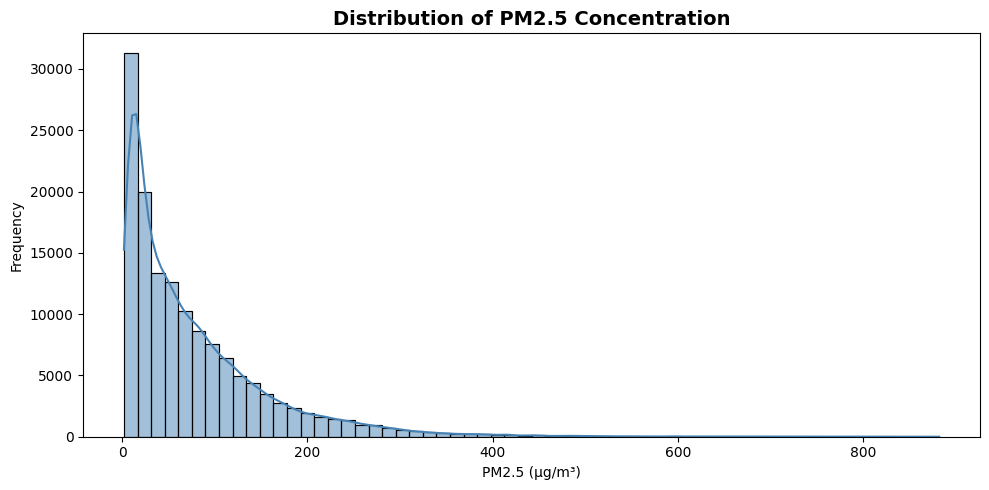

In [31]:
# Distribution of PM2.5 across all stations
plt.figure(figsize=(10, 5))
sns.histplot(df['PM2.5'], bins=60, kde=True, color='steelblue')
plt.title('Distribution of PM2.5 Concentration', fontsize=14, fontweight='bold')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observation:** The PM2.5 distribution is heavily right-skewed, with most readings concentrated at lower values but a long tail extending to very high concentrations (above 300 µg/m³). This indicates frequent moderate pollution levels with occasional severe pollution episodes, which is characteristic of Beijing's air quality patterns.

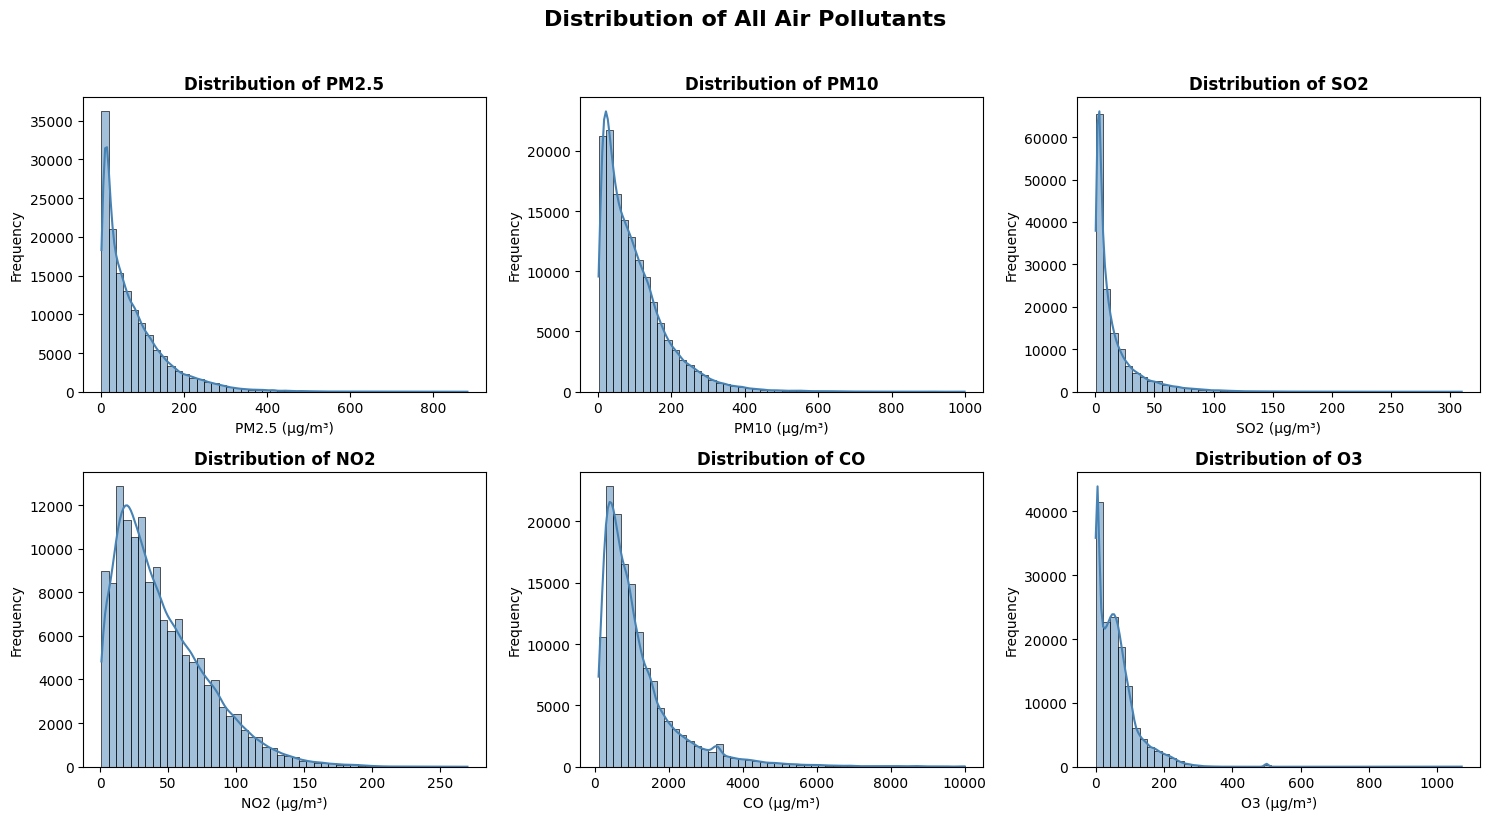

In [32]:
# Distribution of all pollutants
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(f'{col} (µg/m³)')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of All Air Pollutants', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** All pollutants show right-skewed distributions, indicating that extreme pollution events are less frequent but do occur. CO shows the widest spread, suggesting high variability in carbon monoxide levels. O3 appears more normally distributed compared to other pollutants, which reflects its photochemical formation pattern driven by sunlight rather than direct emission.

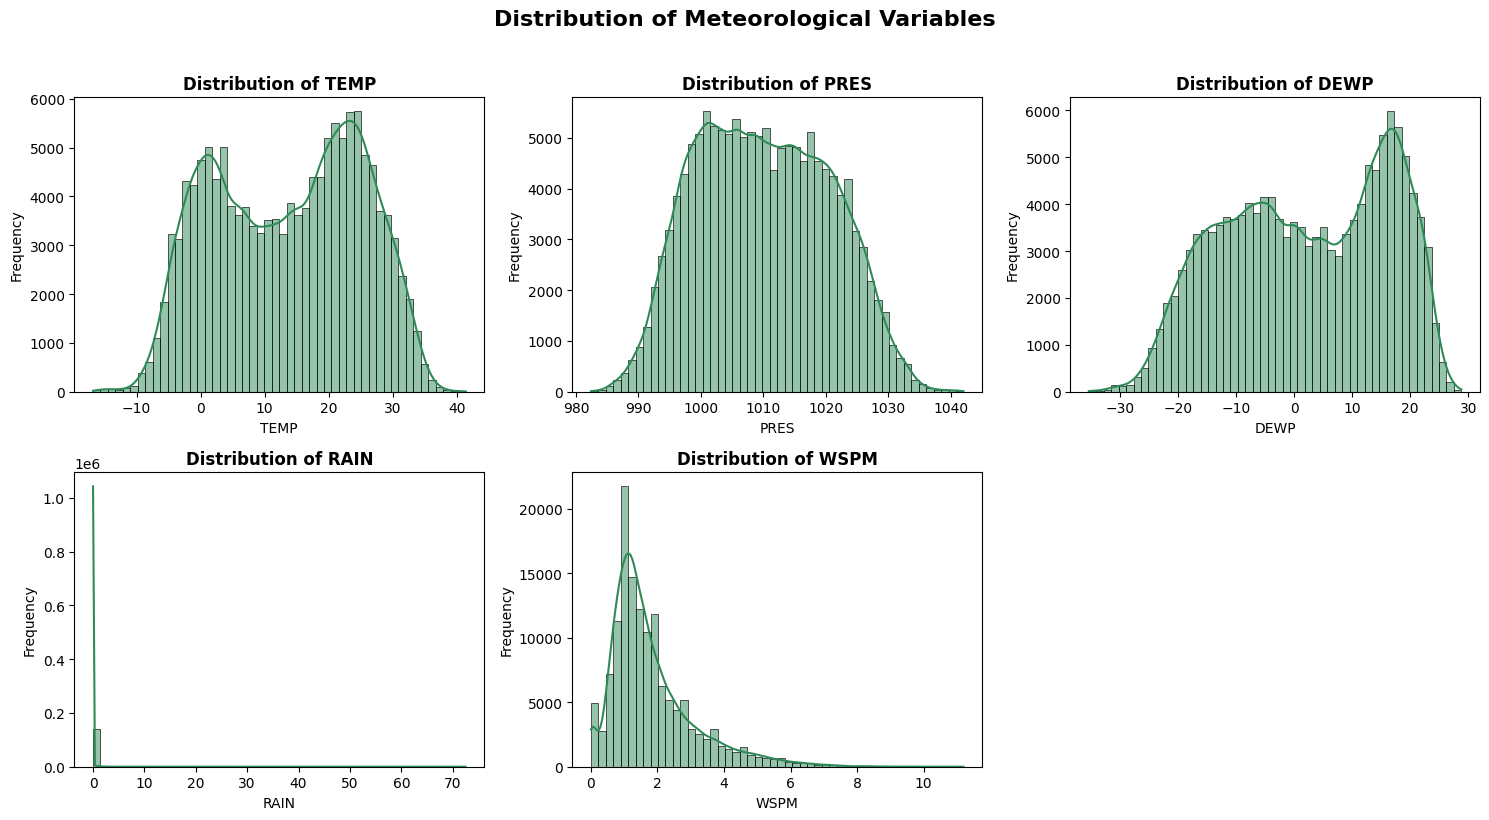

In [33]:
# Distribution of meteorological variables
met_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(met_vars):
    sns.histplot(df[col], bins=50, kde=True, ax=axes[i], color='seagreen')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide the empty 6th subplot
axes[5].set_visible(False)

plt.suptitle('Distribution of Meteorological Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** Temperature (TEMP) shows a bimodal distribution reflecting Beijing's distinct summer and winter seasons. Pressure (PRES) is approximately normally distributed. Rainfall (RAIN) is extremely right-skewed as most hours record zero rainfall, with rare high-rainfall events. Wind speed (WSPM) is also right-skewed, indicating that calm conditions are more common than strong winds.

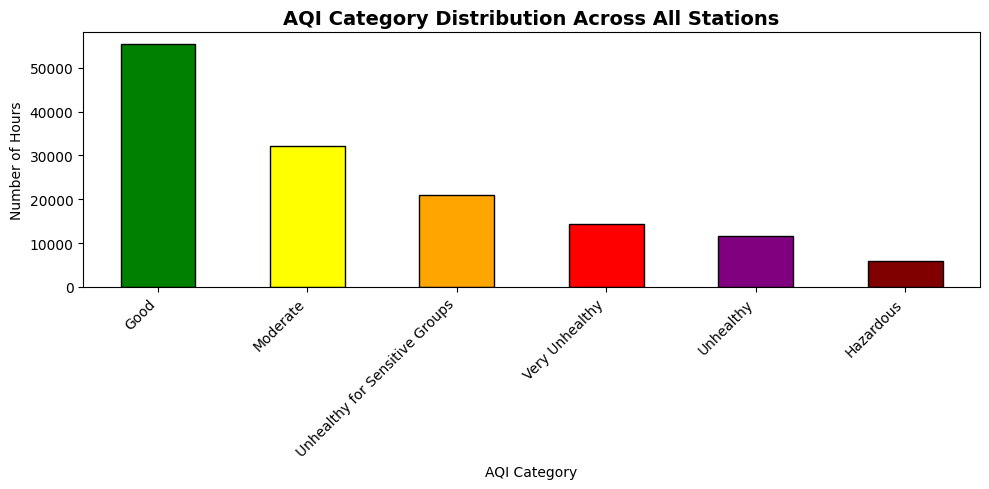

AQI_Category
Good                              55299
Moderate                          32226
Unhealthy for Sensitive Groups    20910
Very Unhealthy                    14280
Unhealthy                         11617
Hazardous                          5924
Name: count, dtype: int64


In [34]:
# AQI Category distribution - Bar Chart
aqi_counts = df['AQI_Category'].value_counts()

plt.figure(figsize=(10, 5))
colors = ['green', 'yellow', 'orange', 'red', 'purple', 'maroon']
aqi_counts.plot(kind='bar', color=colors[:len(aqi_counts)], edgecolor='black')
plt.title('AQI Category Distribution Across All Stations', fontsize=14, fontweight='bold')
plt.xlabel('AQI Category')
plt.ylabel('Number of Hours')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(aqi_counts)

**Observation:** The majority of hourly readings fall in the 'Good' and 'Moderate' categories, however a significant proportion fall in 'Unhealthy' and above categories. This highlights that while Beijing's air quality has some acceptable periods, pollution at harmful levels is not uncommon, underlining the importance of continued monitoring and emission controls.

#### **Bivariate Analysis**
Bivariate analysis explores the relationship between pairs of variables to identify trends and correlations.

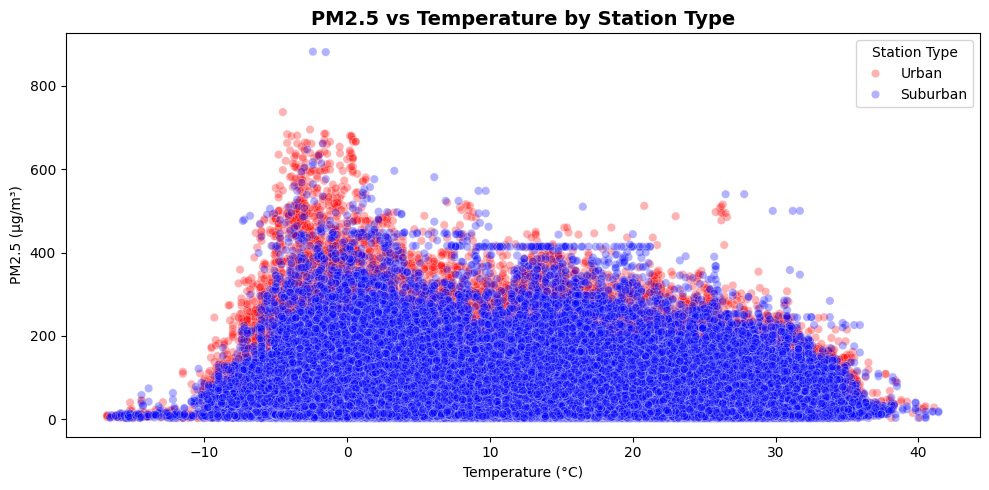

In [35]:
# Bivariate: PM2.5 vs Temperature - Scatter Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='TEMP', y='PM2.5', hue='station_type',
                alpha=0.3, palette={'Urban': 'red', 'Suburban': 'blue'})
plt.title('PM2.5 vs Temperature by Station Type', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend(title='Station Type')
plt.tight_layout()
plt.show()

**Observation:** There is a negative relationship between temperature and PM2.5, with higher PM2.5 concentrations observed at lower temperatures. This is consistent with winter heating activity and reduced atmospheric mixing in cold weather. Urban stations (red) generally show higher PM2.5 levels than suburban stations (blue) across all temperatures, confirming the urban heat island and pollution effect.

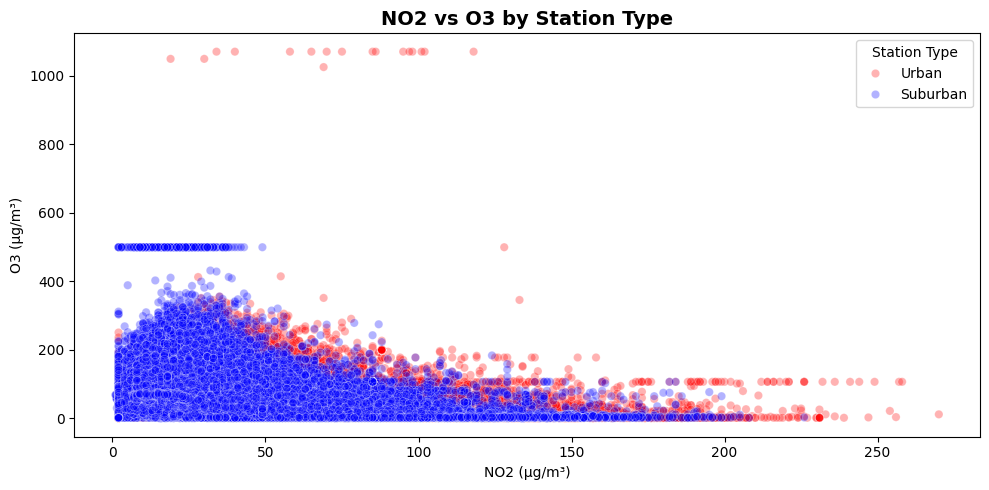

In [36]:
# Bivariate: NO2 vs O3 - Scatter Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='NO2', y='O3', hue='station_type',
                alpha=0.3, palette={'Urban': 'red', 'Suburban': 'blue'})
plt.title('NO2 vs O3 by Station Type', fontsize=14, fontweight='bold')
plt.xlabel('NO2 (µg/m³)')
plt.ylabel('O3 (µg/m³)')
plt.legend(title='Station Type')
plt.tight_layout()
plt.show()

**Observation:** A clear negative relationship is visible between NO2 and O3 — when NO2 levels are high, O3 tends to be low and vice versa. This is consistent with the known atmospheric chemistry where NO2 reacts with ozone (O3), consuming it. Urban stations show higher NO2 and lower O3 compared to suburban stations, reflecting higher vehicle emissions in the urban core.

/tmp/ipykernel_1163/2895529909.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='PM2.5', order=season_order,


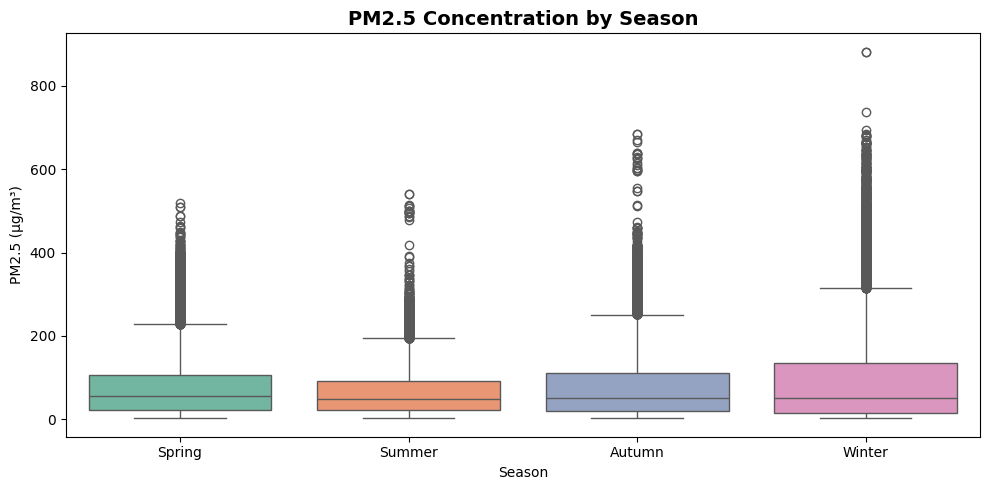

In [37]:
# Bivariate: PM2.5 by Season - Box Plot
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='season', y='PM2.5', order=season_order,
            palette='Set2')
plt.title('PM2.5 Concentration by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

**Observation:** Winter shows the highest PM2.5 concentrations with the widest spread, while Summer records the lowest median PM2.5. This seasonal pattern is driven by increased coal and biomass burning for heating in winter, combined with lower wind speeds and temperature inversions that trap pollutants near the ground. Summer's higher temperatures and stronger winds help to disperse pollution more effectively.

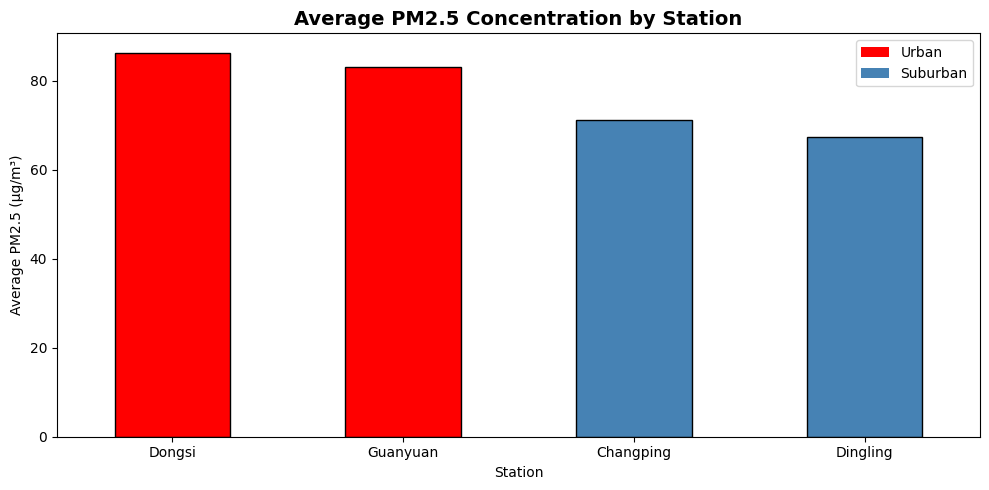

In [38]:
# Average PM2.5 by Station - Bar Chart
avg_pm25 = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['red' if s in ['Dongsi', 'Guanyuan'] else 'steelblue' for s in avg_pm25.index]
avg_pm25.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Average PM2.5 Concentration by Station', fontsize=14, fontweight='bold')
plt.xlabel('Station')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.xticks(rotation=0)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Urban'),
                   Patch(facecolor='steelblue', label='Suburban')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

**Observation:** Urban stations (Dongsi and Guanyuan, shown in red) record higher average PM2.5 levels compared to suburban stations (Dingling and Changping, shown in blue). This confirms the expected urban-suburban pollution gradient, where dense traffic, commercial activity, and higher population density in the urban core contribute significantly to elevated particulate matter concentrations.

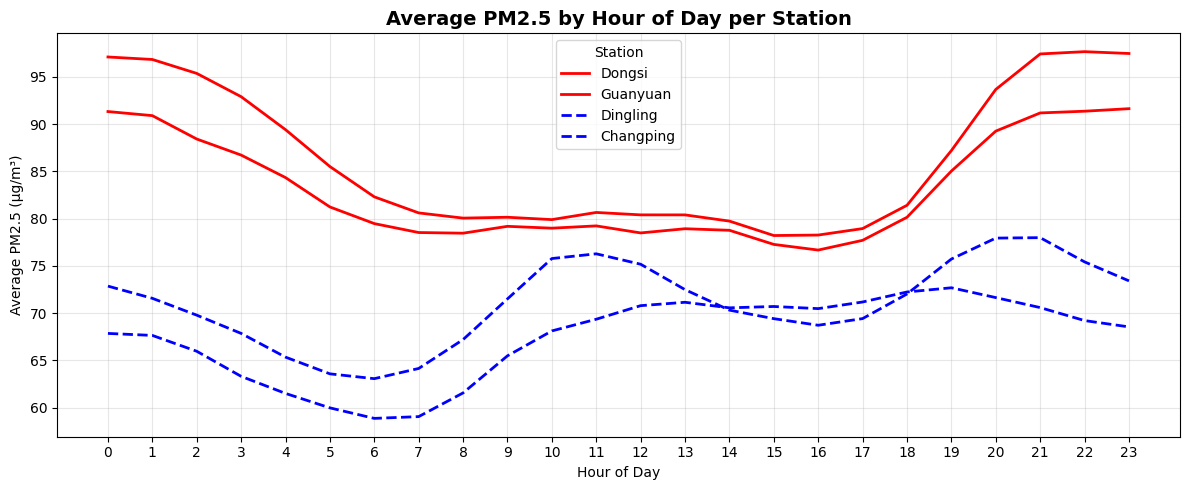

In [39]:
# Average PM2.5 by Hour of Day - Line Chart
hourly_avg = df.groupby(['hour', 'station'])['PM2.5'].mean().reset_index()

plt.figure(figsize=(12, 5))
for station in df['station'].unique():
    data = hourly_avg[hourly_avg['station'] == station]
    color = 'red' if station in ['Dongsi', 'Guanyuan'] else 'blue'
    linestyle = '-' if station in ['Dongsi', 'Guanyuan'] else '--'
    plt.plot(data['hour'], data['PM2.5'], label=station,
             color=color, linestyle=linestyle, linewidth=2)

plt.title('Average PM2.5 by Hour of Day per Station', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.xticks(range(0, 24))
plt.legend(title='Station')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** PM2.5 levels follow a clear diurnal pattern across all stations, with concentrations peaking in the early morning hours (around 6–9am) corresponding to morning rush hour traffic, and again in the late evening. A dip is observed during midday when solar radiation increases atmospheric mixing and disperses pollutants. Urban stations consistently record higher PM2.5 throughout the day.

#### **Multivariate Analysis**
Multivariate analysis examines relationships between more than two variables simultaneously to reveal deeper patterns and interactions in the dataset.

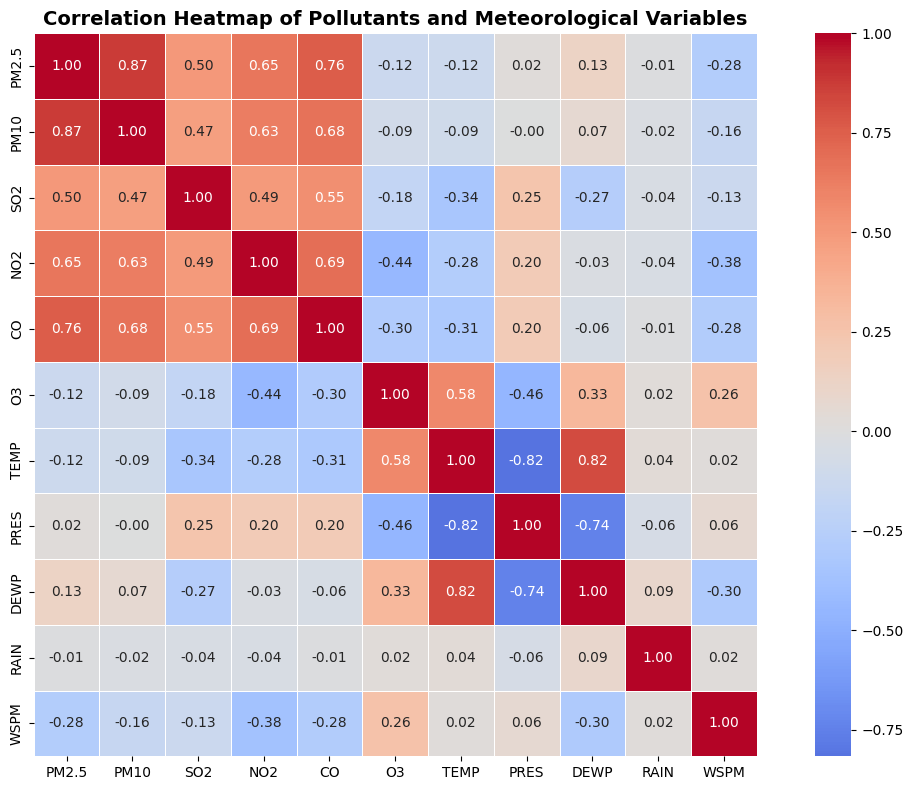

In [40]:
# Correlation Heatmap
corr_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

plt.figure(figsize=(12, 8))
correlation_matrix = df[corr_cols].corr()
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap of Pollutants and Meteorological Variables',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The correlation heatmap reveals several important relationships. PM2.5 and PM10 are strongly positively correlated (>0.8), indicating they share common emission sources. CO shows strong positive correlation with PM2.5 and NO2, suggesting traffic and combustion as shared sources. O3 shows a negative correlation with NO2, CO and PM2.5, confirming the inverse photochemical relationship. Temperature (TEMP) is negatively correlated with PM2.5, consistent with the seasonal patterns observed earlier. These correlations provide valuable guidance for feature selection in model building.

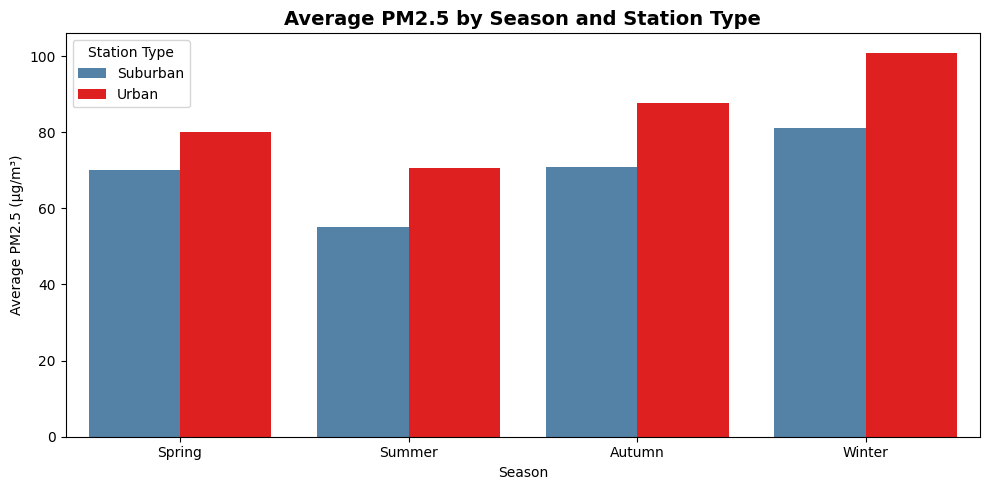

In [41]:
# Multivariate: Seasonal PM2.5 by Station Type - Grouped Bar Chart
seasonal_avg = df.groupby(['season', 'station_type'])['PM2.5'].mean().reset_index()
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

plt.figure(figsize=(10, 5))
sns.barplot(data=seasonal_avg, x='season', y='PM2.5',
            hue='station_type', order=season_order,
            palette={'Urban': 'red', 'Suburban': 'steelblue'})
plt.title('Average PM2.5 by Season and Station Type', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.legend(title='Station Type')
plt.tight_layout()
plt.show()

**Observation:** Urban stations consistently record higher PM2.5 than suburban stations across all seasons. The urban-suburban gap is most pronounced in Winter, suggesting that winter heating activities disproportionately affect urban areas. Both station types follow the same seasonal trend, confirming that the meteorological factors driving seasonal variation affect the entire Beijing region, while local emission sources amplify pollution in urban areas.

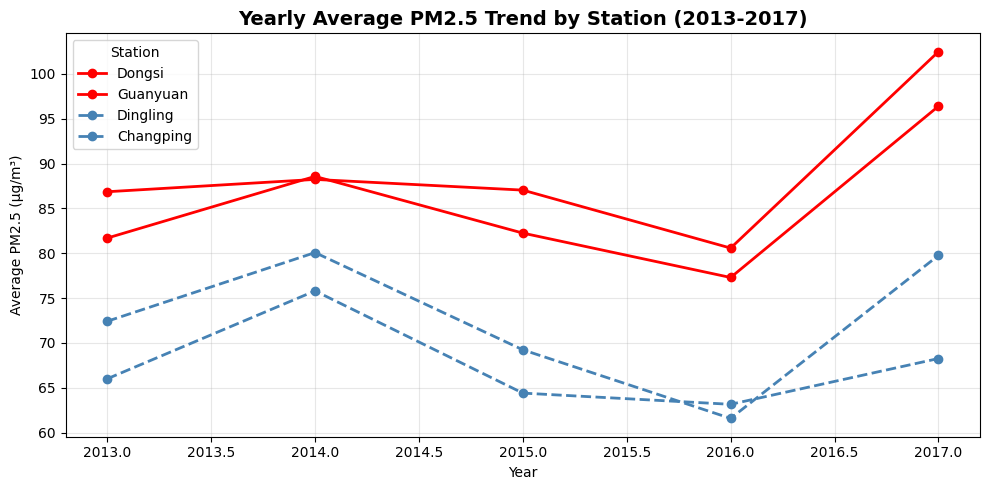

In [42]:
# Yearly PM2.5 trend by station - Line Chart
yearly_avg = df.groupby(['year', 'station'])['PM2.5'].mean().reset_index()

plt.figure(figsize=(10, 5))
for station in df['station'].unique():
    data = yearly_avg[yearly_avg['station'] == station]
    color = 'red' if station in ['Dongsi', 'Guanyuan'] else 'steelblue'
    linestyle = '-' if station in ['Dongsi', 'Guanyuan'] else '--'
    plt.plot(data['year'], data['PM2.5'], marker='o', label=station,
             color=color, linestyle=linestyle, linewidth=2)

plt.title('Yearly Average PM2.5 Trend by Station (2013-2017)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average PM2.5 (µg/m³)')
plt.legend(title='Station')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** The yearly trend shows fluctuating PM2.5 levels across the 2013–2017 period. Some stations show a slight declining trend in later years, which may reflect the impact of Beijing's emission control policies introduced around 2013–2014. Urban stations maintain consistently higher PM2.5 than suburban stations throughout all years, reinforcing the urban-suburban pollution gradient identified throughout this analysis.

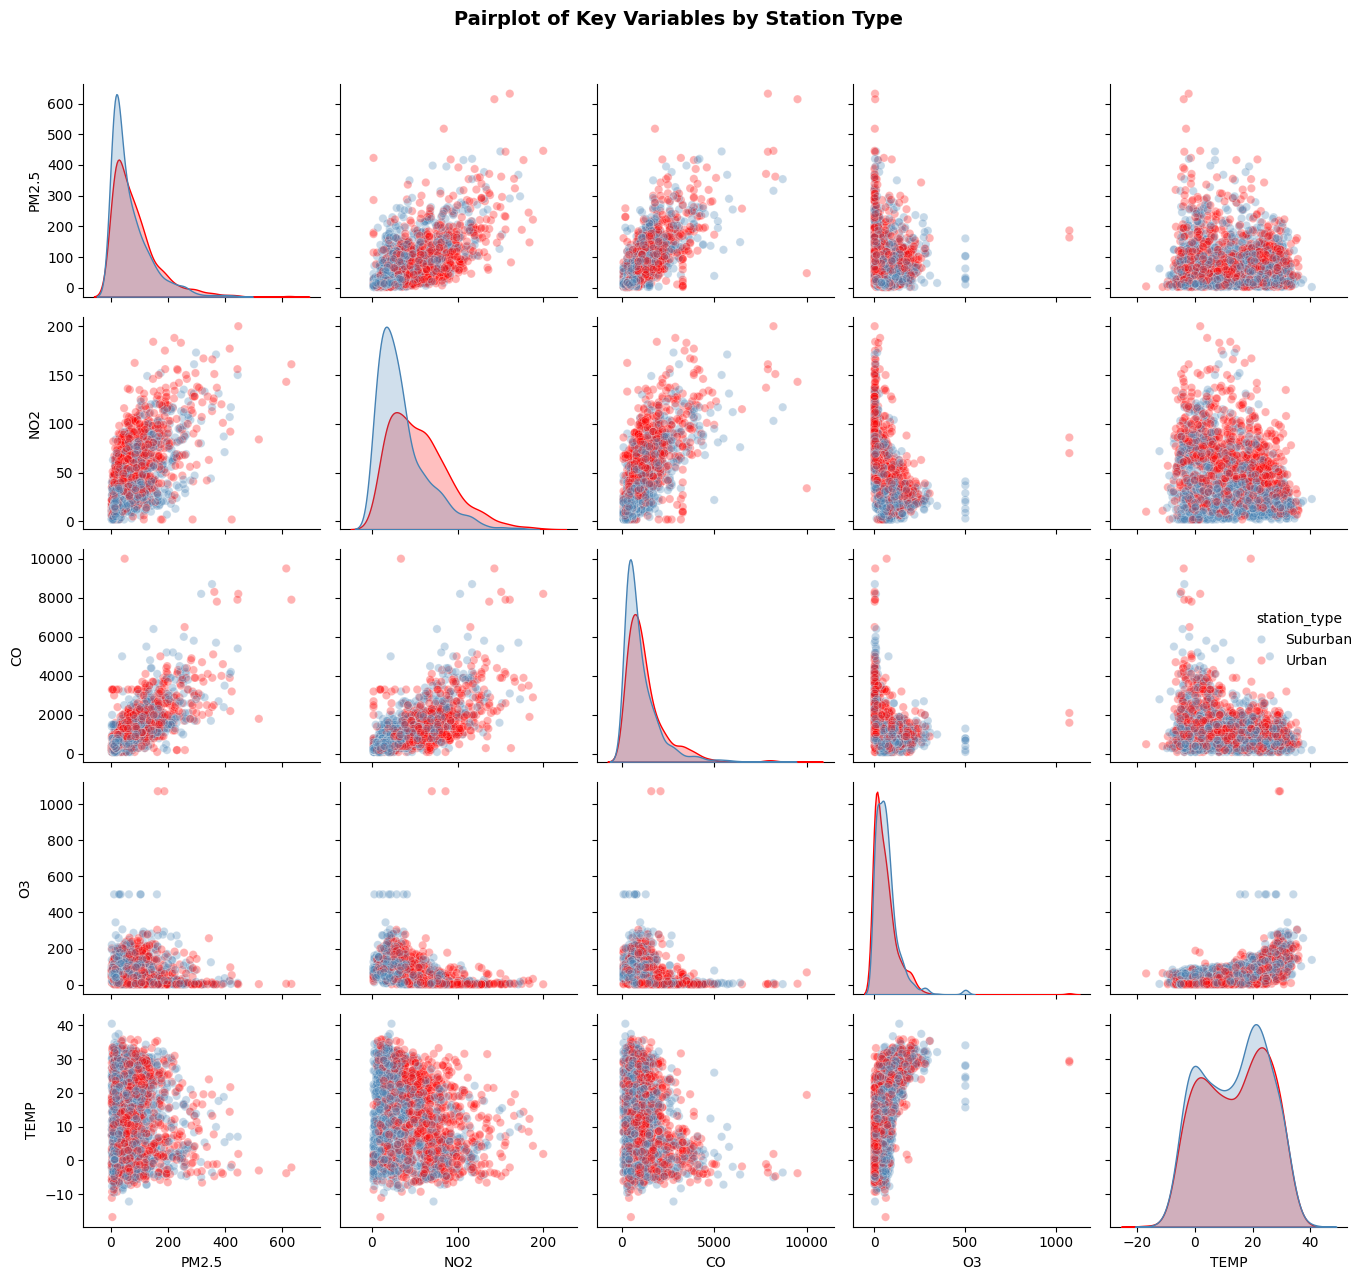

In [43]:
# Pairplot of key pollutants coloured by station type
pairplot_cols = ['PM2.5', 'NO2', 'CO', 'O3', 'TEMP', 'station_type']
sample_df = df[pairplot_cols].sample(2000, random_state=42)

sns.pairplot(sample_df, hue='station_type',
             palette={'Urban': 'red', 'Suburban': 'steelblue'},
             plot_kws={'alpha': 0.3},
             diag_kind='kde')
plt.suptitle('Pairplot of Key Variables by Station Type',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** The pairplot confirms the relationships identified in the correlation heatmap. The strong positive relationship between PM2.5 and CO and NO2 is clearly visible, as is the negative relationship between O3 and other pollutants. Urban stations (red) cluster at higher values for PM2.5, CO and NO2, while suburban stations (blue) show lower values. The temperature distributions are similar between station types, confirming that meteorological conditions are region-wide while pollution levels are influenced by local emissions.

In [44]:
# Statistical Summary by Station
print("Statistical Summary of PM2.5 by Station:\n")
summary = df.groupby('station')['PM2.5'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
summary.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
display(summary.style.background_gradient(cmap='Reds'))

Statistical Summary of PM2.5 by Station:



,Mean,Median,Std Dev,Min,Max
station,,,,,
Changping,71.120000,47.000000,72.420000,2.000000,882.000000
Dingling,67.430000,41.000000,74.820000,3.000000,881.000000
Dongsi,86.310000,61.000000,86.340000,3.000000,737.000000
Guanyuan,83.050000,59.000000,81.310000,2.000000,680.000000


**Key Insights Summary:**

1. **Urban stations (Dongsi, Guanyuan) consistently record higher PM2.5** than suburban stations (Dingling, Changping), confirming the urban pollution gradient.
2. **Winter has the highest pollution levels** across all stations due to heating emissions and poor atmospheric dispersion.
3. **PM2.5 follows a clear diurnal pattern**, peaking during morning and evening rush hours, indicating traffic as a major source.
4. **Strong positive correlations exist between PM2.5, PM10, CO and NO2**, suggesting shared combustion emission sources.
5. **O3 and NO2 are inversely related**, consistent with known atmospheric photochemical reactions.
6. **PM2.5 levels show a slight declining trend** over 2013–2017, potentially reflecting Beijing's pollution control measures introduced during this period.